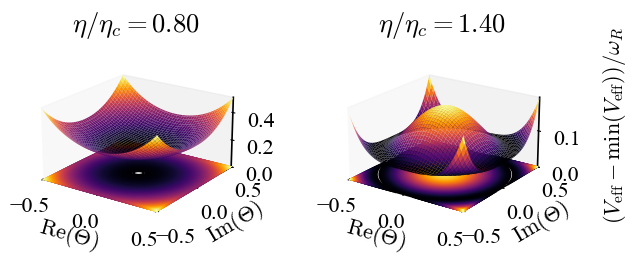

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load data
# ============================================================

data = np.load("Figure_20_data.npz")

X = data["X"]
Y = data["Y"]
phi2 = data["phi2"]

eta_list = data["eta_list"]

eta_c = data["eta_c"].item()
omega_0 = data["omega_0"].item()
omega_R = data["omega_R"].item()

# ============================================================
# PRA Style
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "cm",
    "font.size": 16,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

# ============================================================
# Figure
# ============================================================

fig = plt.figure(figsize=(6.5,2.8))

ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

axes = [ax1, ax2]

# ============================================================
# Plot
# ============================================================

for ax, eta in zip(axes, eta_list):

    h1 = omega_0
    h2 = omega_R*(1-eta**2/eta_c**2)
    h3 = omega_R*eta**2/eta_c**2

    V = (h1+h2*phi2+h3*phi2**2)/omega_R
    V -= V.min()

    lift = 0.5*(V.max()-V.min())
    Vsurf = V + lift

    ax.plot_surface(
        X,
        Y,
        Vsurf,
        cmap="inferno",
        edgecolor="none",
        linewidth=0
    )

    ax.contour(
        X,
        Y,
        V,
        zdir='z',
        offset=0,
        cmap='inferno',
        levels=800
    )

    ax.set_xlim(-0.5,0.5)
    ax.set_ylim(-0.5,0.5)
    ax.set_zlim(0,Vsurf.max())

    ax.set_xlabel(r'$\mathrm{Re}(\Theta)$')
    ax.set_ylabel(r'$\mathrm{Im}(\Theta)$')
    ax.set_zlabel("")

    ax.set_title(r'$\eta/\eta_c=%.2f$'%(eta/eta_c))

    ax.view_init(elev=20, azim=-55)
    ax.grid(False)
    ax.set_box_aspect((1,1,0.55))

fig.text(
    0.98,
    0.5,
    r'$(V_{\rm eff}-\min(V_{\rm eff}))/\omega_R$',
    rotation=90,
    va='center'
)

plt.tight_layout()
plt.show()